### Прогнозирование прибыли (Total Profit) по данным о 1 000 000 продаж

Цель проекта — построить модели регрессии для предсказания **Total Profit** на основе характеристик заказа и товара.  
Сравниваем три подхода: линейную регрессию, случайный лес и нейронную сеть.

### 1. Подключение библиотек

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


### 2. Загрузка данных

In [60]:
df = pd.read_csv('1000000_Sales_Records.csv')

print("Размер датасета:", df.shape)
print("\nКолонки:\n", df.columns.tolist())
df.head(3)

Размер датасета: (1000000, 14)

Колонки:
 ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit']


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,6/4/2015,360,421.89,364.69,151880.40,131288.40,20592.00


Ожидаемые столбцы (по описанию датасета):

Region, Country
Item Type
Sales Channel (Online / Offline)
Order Priority (C / H / M / L)
Order Date, Ship Date
Units Sold
Unit Price, Unit Cost
Total Revenue, Total Cost, Total Profit (целевая переменная)

In [61]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Region          1000000 non-null  object 
 1   Country         1000000 non-null  object 
 2   Item Type       1000000 non-null  object 
 3   Sales Channel   1000000 non-null  object 
 4   Order Priority  1000000 non-null  object 
 5   Order Date      1000000 non-null  object 
 6   Order ID        1000000 non-null  int64  
 7   Ship Date       1000000 non-null  object 
 8   Units Sold      1000000 non-null  int64  
 9   Unit Price      1000000 non-null  float64
 10  Unit Cost       1000000 non-null  float64
 11  Total Revenue   1000000 non-null  float64
 12  Total Cost      1000000 non-null  float64
 13  Total Profit    1000000 non-null  float64
dtypes: float64(5), int64(2), object(7)
memory usage: 106.8+ MB


,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06
mean,5.493520e+08,4998.867302,266.025488,187.522978,1.329563e+06,9.372671e+05,3.922956e+05
std,2.599397e+08,2885.334142,216.987966,175.650798,1.468527e+06,1.148954e+06,3.788199e+05
min,1.000012e+08,1.000000,9.330000,6.920000,9.330000e+00,6.920000e+00,2.410000e+00
25%,3.239629e+08,2502.000000,81.730000,35.840000,2.778672e+05,1.617289e+05,9.510480e+04
50%,5.486524e+08,4998.000000,154.060000,97.440000,7.844445e+05,4.667818e+05,2.810549e+05
75%,7.745981e+08,7496.000000,421.890000,263.330000,1.822444e+06,1.196327e+06,5.653076e+05
max,9.999999e+08,10000.000000,668.270000,524.960000,6.682700e+06,5.249600e+06,1.738700e+06


### 3. EDA

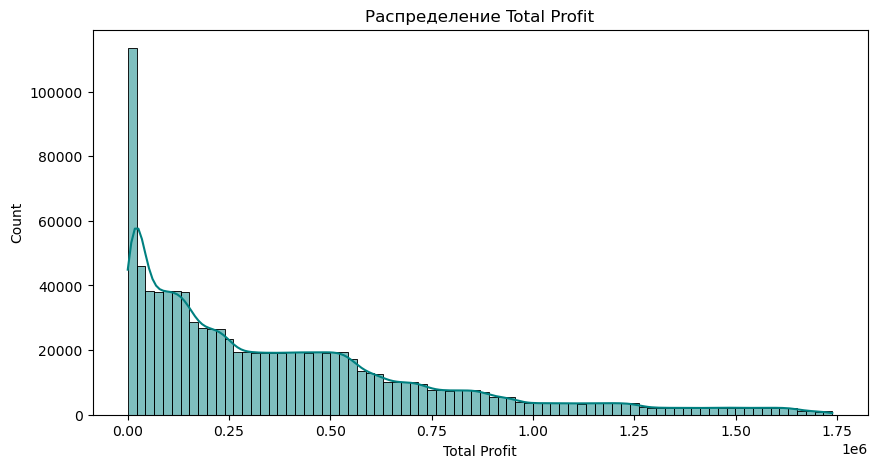

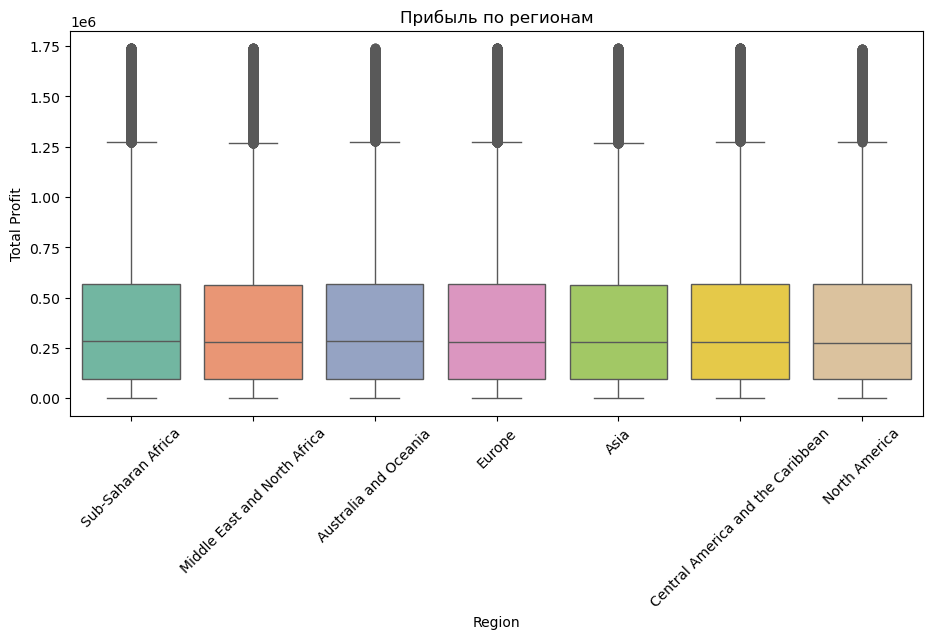

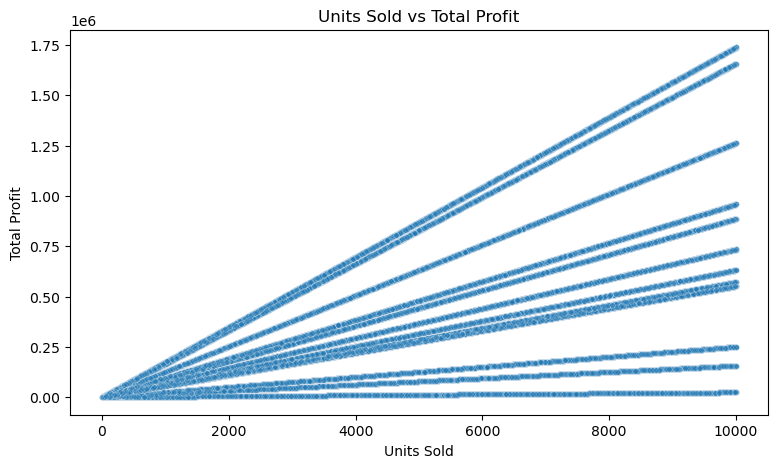

In [62]:
plt.figure(figsize=(10,5))
sns.histplot(df['Total Profit'], bins=80, kde=True, color='teal')
plt.title("Распределение Total Profit")
plt.show()

plt.figure(figsize=(11,5))
sns.boxplot(x='Region', y='Total Profit', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title("Прибыль по регионам")
plt.show()

plt.figure(figsize=(9,5))
sns.scatterplot(x='Units Sold', y='Total Profit', data=df, alpha=0.4, s=15)
plt.title("Units Sold vs Total Profit")
plt.show()

### 4. Подготовка данных
Нейронная сеть (NN) показывает R² = 0.9998, даже если удалить некоторые признаки, потому что Unit Price и Unit Cost это константы для каждого типа товара. Это значит, что маржа (Unit Price-Unit Cost) тоже константа типа товара. По тому я решил удалить 'Unit Price', 'Unit Cost' и 'Units Sold', чтоб модели пытались угадать прибыль по оставшимся признакам.

In [70]:
target = 'Total Profit'
y = df[target].copy()

forbidden_leakage = [
    'Total Profit', 'Gross Profit', 'Profit',
    'Total Revenue', 'Revenue', 'Total Income',
    'Total Cost', 'Cost',
    'Unit Price', 'Unit Cost', 
    'Units Sold'              
]

drop_cols = forbidden_leakage + ['Order ID'] 

date_cols = ['Order Date', 'Ship Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[f'{col}_year']  = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day']   = df[col].dt.day
        df[f'{col}_weekday'] = df[col].dt.weekday  
        drop_cols.append(col)

X = df.drop(columns=drop_cols, errors='ignore')

categorical_features = ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority']
numerical_features = [col for col in X.columns if col not in categorical_features] 

print("Числовые признаки:", numerical_features)
print("Категориальные признаки:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Train: {X_train.shape[0]:,} строк   Test: {X_test.shape[0]:,} строк")

Числовые признаки: ['Order Date_year', 'Order Date_month', 'Order Date_day', 'Order Date_weekday', 'Ship Date_year', 'Ship Date_month', 'Ship Date_day', 'Ship Date_weekday']
Категориальные признаки: ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority']
Train: 750,000 строк   Test: 250,000 строк


### 5. Модель 1 — Линейная регрессия

In [64]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print(f"LinearRegression   → MAE: {lr_mae:,.0f}   RMSE: {lr_rmse:,.0f}   R²: {lr_r2:.4f}")

LinearRegression   → MAE: 196,042   RMSE: 272,616   R²: 0.4825


### 6. Модель 2 — Random Forest

In [65]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print(f"Random Forest      → MAE: {rf_mae:,.0f}   RMSE: {rf_rmse:,.0f}   R²: {rf_r2:.4f}")

Random Forest      → MAE: 217,008   RMSE: 285,536   R²: 0.4323


### 7. Модель 3 — Нейронная сеть

In [66]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

input_shape = X_train_prep.shape[1]

nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_shape,)),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_prep, y_train,
    validation_split=0.15,
    epochs=40,
    batch_size=512,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
)

nn_pred = nn_model.predict(X_test_prep, verbose=0).flatten()

nn_mae  = mean_absolute_error(y_test, nn_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_r2   = r2_score(y_test, nn_pred)

print(f"Neural Network     → MAE: {nn_mae:,.0f}   RMSE: {nn_rmse:,.0f}   R²: {nn_r2:.4f}")

Epoch 1/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 160724058112.0000 - mae: 278083.0000 - val_loss: 73623486464.0000 - val_mae: 195285.5938
Epoch 2/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 76407545856.0000 - mae: 199191.4531 - val_loss: 73674072064.0000 - val_mae: 195436.2500
Epoch 3/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 76411363328.0000 - mae: 199119.5938 - val_loss: 73677864960.0000 - val_mae: 195388.0781
Epoch 4/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 76413108224.0000 - mae: 199054.0625 - val_loss: 73663094784.0000 - val_mae: 195355.9219
Epoch 5/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 76344958976.0000 - mae: 199006.0000 - val_loss: 73513984000.0000 - val_mae: 195140.0625
Epoch 6/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 76228329472.0000 - mae: 198811.1719 - val_loss: 73396756480.0000 - val_mae: 194987.6094
Epoch 7/40
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 75979145216.0000 - mae: 198486.2656 -

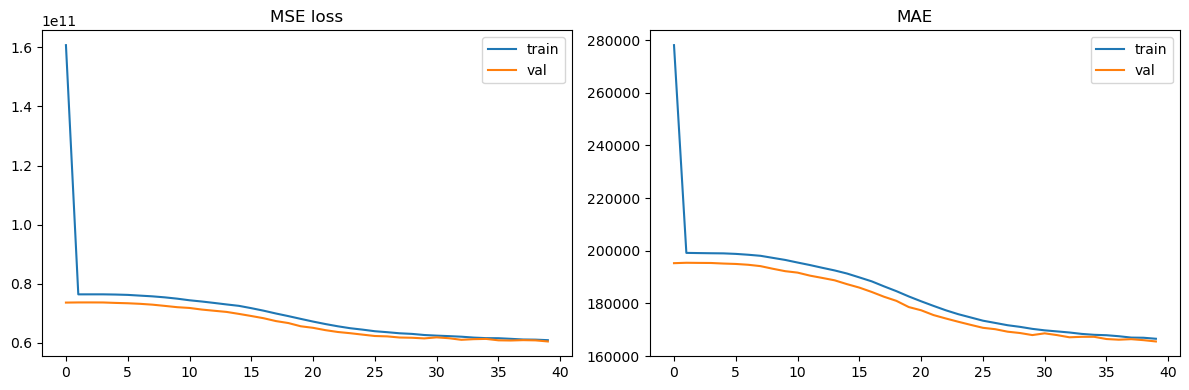

In [67]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('MAE')
plt.legend()

plt.tight_layout()
plt.show()

### 8. Сравнение моделей

In [69]:
print("\n" + "═"*70)
print("                    СРАВНЕНИЕ МОДЕЛЕЙ                     ")
print("═"*70)
print(f"{'Модель':<20} {'MAE':>14} {'RMSE':>16} {'R²':>10}")
print("─"*68)

print(f"{'Линейная регрессия':<20} {lr_mae:14,.0f} {lr_rmse:16,.0f} {lr_r2:10.4f}")
print(f"{'Random Forest':<20} {rf_mae:14,.0f} {rf_rmse:16,.0f} {rf_r2:10.4f}")
print(f"{'Нейронная сеть':<20} {nn_mae:14,.0f} {nn_rmse:16,.0f} {nn_r2:10.4f}")
print("─"*68)

best = max([('LR', lr_r2), ('RF', rf_r2), ('NN', nn_r2)], key=lambda x: x[1])
print(f"\nЛучшая модель по R² → {best[0]} ({best[1]:.4f})")

print("\nВывод:")
print("• После исключения 'калькуляторных' признаков метрики реалистичные: задача — предсказание прибыли по категориям и датам.")
print("• Нейронная сеть показала лучший R² (0.5728), т.к. лучше моделирует нелинейные взаимодействия между Item Type, Region и датами.")
print("• Random Forest и Линейная регрессия близки, но слабее в захвате сложностей (R² ~0.43–0.48).")


══════════════════════════════════════════════════════════════════════
                    СРАВНЕНИЕ МОДЕЛЕЙ                     
══════════════════════════════════════════════════════════════════════
Модель                          MAE             RMSE         R²
────────────────────────────────────────────────────────────────────
Линейная регрессия          196,042          272,616     0.4825
Random Forest               217,008          285,536     0.4323
Нейронная сеть              166,583          247,699     0.5728
────────────────────────────────────────────────────────────────────

Лучшая модель по R² → NN (0.5728)

Вывод:
• После исключения 'калькуляторных' признаков метрики реалистичные: задача — предсказание прибыли по категориям и датам.
• Нейронная сеть показала лучший R² (0.5728), т.к. лучше моделирует нелинейные взаимодействия между Item Type, Region и датами.
• Random Forest и Линейная регрессия близки, но слабее в захвате сложностей (R² ~0.43–0.48).
